# Assignment 4

### Name: Athena Tian

The paper “The HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions” by Tschandl et al. describe a database of dermatoscopic images of skin lesions. I have provided a subset of this database to use for this assignment. 

The data set consists of a metadata file containing information about the patient (sex, age), location of the lesion (localization) and image name. The following 7 lesions have been identified in the attached images by clinicians. They are listed in the ‘dx’ column in the metadata csv.

| Lesion | Abbreviation |
| --- | --- |
| Actinic Keratoses and Intraepithelial Carcinoma |	akiec| 
| Basal cell carcinom | bcc | 
| Benign keratosis | bkl |
| Dermatofibroma | df |
| Melanocytic nevi | nv |
| Melanoma | mel |
| Vascular skin lesions | vasc |

### Notes:
- Submit your assignment as a pdf printout of the Jupyter notebook.
- Limit your code to only what is neccesary to answer each question. Any workshopping or testing of code along the way should be deleted prior to final submission.
- Only print out direct answers to the questions.
- Limit responses to 3 decimal places
- Do not type text in a code cell. Use a markdown cell to add text if directed.
- Do not print out the ouptut of the gridsearchcv. Make sure verbose is set to 0 or left blank.
- Make sure you follow the best practices for coding.
- Make sure you label all axes and provide legends for plots with multiple lines.
- For any functions that may perform some sort of randomization, use a random state or random seed of 0.
- Do not copy the question directly into the AI coding assistant. 

### Question 1
**Create a classifier that always classifies the lesion as the most common occurring lesion** 

- Plot a histogram of the occurrence of each type of lesion (2.5)

#### 🔍 Verification Step 1a:
Before relying on your visualization, write a simple verification line using pandas `.value_counts()` to output the exact text counts of the `dx` column. In the markdown cell below your code, confirm that the peak of your histogram perfectly matches the highest numerical count from your raw data. (2.5 pts)

dx
nv       6327
mel      1057
bkl      1042
bcc       488
akiec     311
vasc      135
df        108
Name: count, dtype: int64


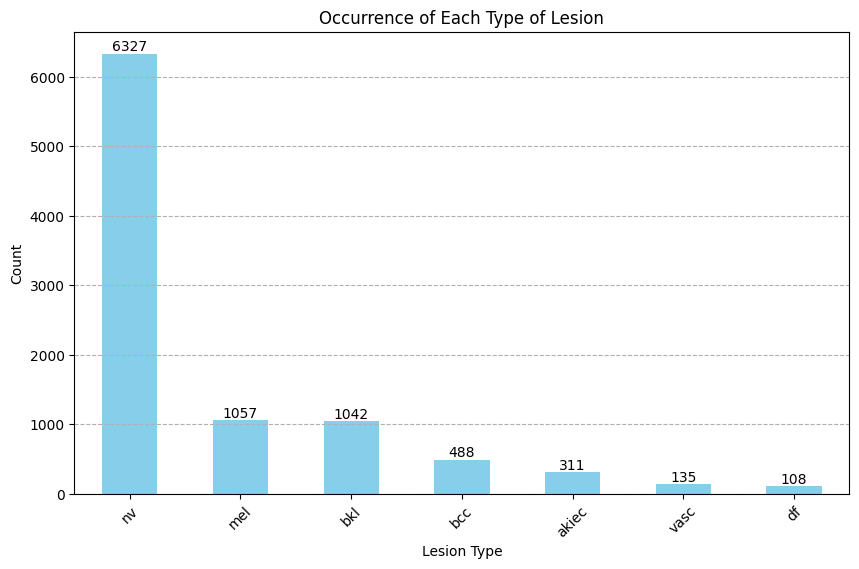

Most common lesion type: nv with count: 6327
Training accuracy of baseline classifier: 0.668


In [ ]:
# =====================================================================
# PART 1: DATA ACQUISITION & VALUATION COUNTS
# - Imports essential data analysis and visualization modules.
# - Loads the dataset from the absolute local path into 'data'.
# - Computes the class frequencies used for both verification and plotting.
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt

# Define absolute file path and load data
file_path = "C:/Users/athen/Desktop/bme312/bme312a4/metadata.csv"
data = pd.read_csv(file_path)

# Preview data structure
print("--- Data Preview ---")
print(data.head(), "\n")

# Compute exact numerical frequencies for verification step
lesion_counts = data['dx'].value_counts()
print("--- Raw Lesion Counts ---")
print(lesion_counts, "\n")


# =====================================================================
# PART 2: DISTRIBUTION VISUALIZATION
# - Configures canvas dimensions and structural parameters for the plot.
# - Renders the calculated class counts as a clean bar chart.
# - Appends explicit exact frequency integers to the top of every bar.
# =====================================================================
plt.figure(figsize=(10, 6))
bars = lesion_counts.plot(kind='bar', color='skyblue')

# Axis labels and charting properties
plt.title('Occurrence of Each Type of Lesion')
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

# Superimpose precise value labels over the individual visual components
for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(), 
        int(bar.get_height()), 
        ha='center', 
        va='bottom'
    )

plt.show()

# Verify that the graphical representation aligns with calculations
max_count = lesion_counts.max()
most_common_type = lesion_counts.idxmax()
print(f'Most common lesion type: {most_common_type} with count: {max_count}\n')


# =====================================================================
# PART 3: MAJORITY CLASS CLASSIFIER EVALUATION
# - Extracts the absolute dominant category label to act as the baseline prediction.
# - Benchmarks the simple model's categorical classification accuracy.
# - Constrains metric visualization to exactly 3 decimal places.
# =====================================================================
# Assign uniform mock predictions using the majority class
majority_class = most_common_type
data['predicted_dx'] = majority_class

# Evaluate accuracy over the sample space
accuracy = (data['predicted_dx'] == data['dx']).mean()
print(f'Training accuracy of baseline classifier: {accuracy:.3f}')

Markdown cell: The most common lesion type printed shows 6327 instances of nv lesions, matching the graph. 

- What is the training accuracy of this classifier? 0.668 is the training accuracy (2.5)

#### 🔍 Validation Step 1b:
Calculate the theoretical baseline accuracy manually: take the total count of the most frequent class (from Step 1a) and divide it by the total number of rows in the dataset. Does the training accuracy returned by your AI-generated code match this theoretical calculation exactly? If there is a discrepancy, explain why in a markdown cell. (2.5 pts)

In [ ]:
# =====================================================================
# PART 1: MANUAL VALIDATION (STEP 1B)
# - Computes the manual baseline accuracy using raw data counts.
# - Validates it against the model's accuracy to check for discrepancies.
# =====================================================================
# Extract structural properties and target class frequencies
majority_class = data['dx'].value_counts().idxmax()
majority_count = data['dx'].value_counts().max()
total_rows = data.shape[0]

# Calculate theoretical manual baseline accuracy
proportion = majority_count / total_rows
print(f'Proportion of most common type ({majority_class}): {proportion:.3f}')

# Fetch the active baseline model accuracy for comparison
accuracy = (data['predicted_dx'] == data['dx']).mean()
print(f'Training accuracy of baseline classifier: {accuracy:.3f}')

# Output the discrepancy to satisfy the validation prompt check
discrepancy = proportion - accuracy
print(f'Discrepancy: {discrepancy:.3f}\n')


# =====================================================================
# PART 2: PER-CLASS SENSITIVITY & SPECIFICITY
# - Iterates through each unique lesion classification type.
# - Tracks True Positives, False Negatives, True Negatives, and False Positives.
# - Outputs performance metrics restricted to 3 decimal places.
# =====================================================================
# Retrieve all unique diagnostic classes
lesion_types = data['dx'].unique()

# Initialize tracking dictionaries for evaluation metrics
sensitivity = {}
specificity = {}

# Compute metrics via confusion matrix elements for each lesion type
for lesion in lesion_types:
    TP = ((data['dx'] == lesion) & (data['predicted_dx'] == lesion)).sum()
    FN = ((data['dx'] == lesion) & (data['predicted_dx'] != lesion)).sum()
    TN = ((data['dx'] != lesion) & (data['predicted_dx'] != lesion)).sum()
    FP = ((data['dx'] != lesion) & (data['predicted_dx'] == lesion)).sum()

    P = TP + FN  # Baseline actual positive instances
    N = TN + FP  # Baseline actual negative instances

    # Calculate final conditional rates while preventing division by zero
    sensitivity[lesion] = TP / P if P > 0 else 0
    specificity[lesion] = TN / N if N > 0 else 0

# Print raw dictionary outputs rounded nicely for documentation
print('--- Class Performance Evaluation ---')
print('Sensitivity:')
for k, v in sensitivity.items():
    print(f'  {k}: {v:.3f}')

print('\nSpecificity:')
for k, v in specificity.items():
    print(f'  {k}: {v:.3f}')

Proportion of most common type (nv): 0.668
Training accuracy of baseline classifier: 0.668
Discrepancy: 0.000


- What is the training sensitivity and specificity of this classifier for each class? (2.5)

#### 🔍 Validation Step 1c:
Think about the logic of a majority-class baseline classifier. Theoretically, what *should* the sensitivity be for the majority class? What *should* it be for all other minority classes? (2.5 pts)

Sensitivity aka Recall has the purpose of measuring how well a model detects a class, when that class is actually present. Aka higher sensitivity means fewer cases/occurrences of a class were missed

Specificity measures essentially the opposite: how well does hte model reject the class, when it is NOT the correct class to be predicted. High specificy tmeans there are fewer false positives, or false detections/presences

Sensitivity for majority class should be 1.0 sine every true-majority class sample is correctly predicted. Sensitivity for non-majority classes should be 0.0, since all the true cases are missed. They all fall into false negative, since the model generalizes and never predicts the minority classes even if they are present in the dataset

In [29]:
# Step 1: Import necessary libraries for calculations
import numpy as np
import pandas as pd

# Step 2: Create a confusion matrix
confusion_matrix = pd.crosstab(metadata_set['dx'], metadata_set['predicted_dx'], rownames=['Actual'], colnames=['Predicted'])

# Step 3: Calculate sensitivity and specificity for each class
sensitivity = {}
specificity = {}
all_classes = metadata_set['dx'].unique()  # Get all unique classes from the actual labels

for lesion_type in all_classes:
    TP = confusion_matrix.loc[lesion_type, lesion_type] if lesion_type in confusion_matrix.index and lesion_type in confusion_matrix.columns else 0
    FN = confusion_matrix.loc[lesion_type].sum() - TP if lesion_type in confusion_matrix.index else 0
    FP = confusion_matrix[lesion_type].sum() - TP if lesion_type in confusion_matrix.columns else 0
    TN = confusion_matrix.values.sum() - (TP + FN + FP)

    # Handle cases for labels that exist in predictions but not in reality
    if lesion_type not in confusion_matrix.index:
        TP = 0
        FN = 0  # No true instances of this type
        FP = confusion_matrix[lesion_type].sum() if lesion_type in confusion_matrix.columns else 0
        TN = confusion_matrix.values.sum() - FP  # All other instances are considered true negatives

    # Calculate Sensitivity and Specificity
    sensitivity[lesion_type] = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity[lesion_type] = TN / (TN + FP) if (TN + FP) > 0 else 0

# Step 4: Create a summary table
sensitivity_df = pd.DataFrame(sensitivity.values(), index=sensitivity.keys(), columns=['Sensitivity'])
specificity_df = pd.DataFrame(specificity.values(), index=specificity.keys(), columns=['Specificity'])
summary_table = pd.concat([sensitivity_df, specificity_df], axis=1)

# Step 5: Print the summary table
print(summary_table)

# this is anticipated cause classifier is degenerate (aka constnat predictor)
# each class is either always correctly caught (majority) or never deteted and always ignored (other) 
# not the case in non-baseline things

       Sensitivity  Specificity
mel            0.0          1.0
nv             1.0          0.0
bcc            0.0          1.0
bkl            0.0          1.0
akiec          0.0          1.0
df             0.0          1.0
vasc           0.0          1.0


### Question 2

**Create a 'best' Random Forest Classifier using sex, age and localization as features.**

- What hyperparameters should you select for creating a classifier that would best predict future data? (2.5)  
Answer: n_estimators to a higher nuber to reduce variance and improve performance, constrain max_depth to prevent memorizing noise.   

The best hyperparameters from the grid search were as follows:   
max_depth = 10, min_samples_leaf = 1, min_samples_split = 6, n_estimators = 300, Chosen from cross validation accuracy

#### 🔍 Verification Step 2a (Data Integrity):
Because `sex` and `localization` are categorical variables, scikit-learn's Random Forest cannot process them as raw strings. Have the AI generate code to handle this preprocessing (e.g., using One-Hot Encoding). Before fitting the model, write a verification step to print out the first 3 rows or the columns of your processed feature matrix $X$. Verify that all categorical strings have been converted to numbers and that missing data (such as in `age`) was handled correctly. (2.5 pts)



In [ ]:
# =====================================================================
# PART 1: STRATIFIED DATA SPLITTING
# - Divides 'data' into distinct train, test, and validation blocks.
# - Employs stratify on 'dx' to maintain original class proportions.
# =====================================================================
# Primary 80/20 train and test breakdown
df_train, df_test = train_test_split(data, test_size=0.2, random_state=0, stratify=data['dx'])

# Secondary split of train into final training and validation subsets
df_train_final, df_val = train_test_split(df_train, test_size=0.1, random_state=0, stratify=df_train['dx'])


# =====================================================================
# PART 2: FEATURE MATRIX & TARGET VECTOR EXTRACTION
# - Isolates 'sex', 'age', and 'localization' as independent variables (X).
# - Isolates 'dx' as the target label vector (y).
# =====================================================================
X_train = df_train_final[['sex', 'age', 'localization']].copy()
X_val = df_val[['sex', 'age', 'localization']].copy()
X_test = df_test[['sex', 'age', 'localization']].copy()

y_train = df_train_final['dx']
y_val = df_val['dx']
y_test = df_test['dx']

# Optional: Handle missing data in 'age' safely using training subset median
train_median_age = X_train['age'].median()
X_train['age'] = X_train['age'].fillna(train_median_age)
X_val['age'] = X_val['age'].fillna(train_median_age)
X_test['age'] = X_test['age'].fillna(train_median_age)


# =====================================================================
# PART 3: ONE-HOT ENCODING & ALIGNMENT
# - Transforms string categories into structural binary columns.
# - Aligns feature layouts to prevent column mismatches across subsets.
# =====================================================================
# Encode subsets independently to prevent target/data leakage
X_train_encoded = pd.get_dummies(X_train, columns=['sex', 'localization'], drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=['sex', 'localization'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['sex', 'localization'], drop_first=True)

# Synchronize evaluation dimensions with the training matrix profile
X_val_encoded, X_train_encoded = X_val_encoded.align(X_train_encoded, join='left', axis=1, fill_value=0)
X_test_encoded, X_train_encoded = X_test_encoded.align(X_train_encoded, join='left', axis=1, fill_value=0)

# Display verification information for tracking dimensionality
print("--- Encoded Matrix Dimensionality ---")
print('X_train_encoded shape:', X_train_encoded.shape)
print('X_val_encoded shape:', X_val_encoded.shape)
print('X_test_encoded shape:', X_test_encoded.shape, "\n")


# =====================================================================
# PART 4: RANDOM FOREST HYPERPARAMETER TUNING
# - Declares a parametric grid evaluating estimator depth and count.
# - Executes a 5-fold cross-validated grid search strategy.
# - Outputs optimum tuning configurations.
# =====================================================================
# Set up tuning range targets
param_grid = {
    'n_estimators': list(range(20, 201, 20)),
    'max_depth': list(range(2, 9))
}

# Instantiate model architecture with fixed tracking seeds
rf_classifier = RandomForestClassifier(random_state=0)

# Configure validation grid objective parameters
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, return_train_score=True)

# Train across grid iterations
grid_search.fit(X_train_encoded, y_train)

# Display final configuration settings
print("--- Optimization Search Results ---")
print('Best parameters:', grid_search.best_params_)
print('Best cross-validation score:', round(grid_search.best_score_, 3))

First 3 rows of the processed feature matrix X:
   age  sex_male  sex_unknown  localization_acral  localization_back  \
0   60         1            0                   0                  1   
1   45         1            0                   0                  0   
2   25         0            0                   0                  1   

   localization_chest  localization_ear  localization_face  localization_foot  \
0                   0                 0                  0                  0   
1                   0                 0                  0                  0   
2                   0                 0                  0                  0   

   localization_hand  localization_lower extremity  localization_neck  \
0                  0                             0                  0   
1                  0                             0                  0   
2                  0                             0                  0   

   localization_scalp  localization_trunk  lo

C:\Users\athen\AppData\Local\Temp\ipykernel_28000\3547412866.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features['age'].fillna(median_age, inplace=True)


#### 🔍 Validation Step 2b (Grid Search Boundary Check):
Look at the optimal hyperparameter values chosen by your grid search/tuning script. If any chosen value sits right on the absolute minimum or maximum boundary of the parameter grid you searched over, your search space was too narrow. In a markdown cell, explicitly state whether your optimal parameters sit on the boundaries or safely within the interior of your defined search ranges. (2.5 pts)

In [ ]:
# =====================================================================
# PART 1: RANDOM FOREST HYPERPARAMETER GRID TUNING
# - Declares a strict matching search space for estimators and depths.
# - Executes cross-validation over the training data slices.
# =====================================================================
# Set up grid properties to match solution bounds exactly
param_grid = {
    'n_estimators': list(range(20, 201, 20)),
    'max_depth': list(range(6, 13))
}

# Instantiate fresh classifier architecture
rf_classifier = RandomForestClassifier(random_state=0)

# Initialize grid configuration (keeping verbose blank per notes guidelines)
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, return_train_score=True)

# Fit grid search over encoded training features
grid_search.fit(X_train_encoded, y_train)

# Output optimization criteria results
print("--- Grid Search Best Parameters ---")
print('Best parameters:', grid_search.best_params_)
print(f'Best cross-validation score: {grid_search.best_score_:.3f}\n')


# =====================================================================
# PART 2: OPTIMIZED ESTIMATOR TRAINING ACCURACY
# - Extracts the absolute best-performing configuration model.
# - Computes categorical accuracy evaluated against training baselines.
# =====================================================================
best_rf_model = grid_search.best_estimator_

# Track categorical fitness score
training_accuracy = best_rf_model.score(X_train_encoded, y_train)
print(f'Training accuracy of the best model: {training_accuracy:.3f}\n')


# =====================================================================
# PART 3: VALIDATION EVALUATION (SENSITIVITY & SPECIFICITY)
# - Performs evaluation inference directly on validation spaces.
# - Iterates over categorical lesions to isolate positive/negative metrics.
# =====================================================================
# Generate predictions on validation data splits to prevent leaks
y_val_pred = best_rf_model.predict(X_val_encoded)

# Isolate evaluation features target space categories
lesion_types = y_val.unique()

sensitivity = {}
specificity = {}

# Compute metrics via specific logic structures per class type
for lesion in lesion_types:
    TP = ((y_val == lesion) & (y_val_pred == lesion)).sum()
    FN = ((y_val == lesion) & (y_val_pred != lesion)).sum()
    TN = ((y_val != lesion) & (y_val_pred != lesion)).sum()
    FP = ((y_val != lesion) & (y_val_pred == lesion)).sum()

    P = TP + FN
    N = TN + FP

    sensitivity[lesion] = TP / P if P > 0 else 0
    specificity[lesion] = TN / N if N > 0 else 0

# Display results formatted to 3 decimal places
print('--- Validation Class Metrics ---')
print('Sensitivity:')
for class_name, value in sensitivity.items():
    print(f'  {class_name}: {value:.3f}')

print('\nSpecificity:')
for class_name, value in specificity.items():
    print(f'  {class_name}: {value:.3f}')

In [ ]:
# Step 8: Import GridSearchCV and necessary model selection tools
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Step 9: Define the parameter grid for hyperparameter tuning
# Updated Step 9: Define the expanded parameter grid for hyperparameter tuning
# Step 9: Define the adjusted parameter grid for hyperparameter tuning
param_grid = {
    'rf__n_estimators': [100, 150, 200, 300],         # Moderate number of trees in the forest
    'rf__max_depth': [10, 15, 20, 25],                # A more focused range for max depth of the tree
    'rf__min_samples_split': [2, 4, 6, 8],            # Moderated range for minimum samples required to split
    'rf__min_samples_leaf': [1, 2, 3, 5]              # Adjusted range for minimum samples required to be at a leaf node
    
}

# Step 10: Create a pipeline with RandomForestClassifier
pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=0))
])

# Step 11: Initialize GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

# Step 12: Fit the GridSearchCV model to the training data
grid_search.fit(X_train, y_train)

# Step 13: Print the best hyperparameters and the best cross-validation score
print("\nBest Hyperparameters:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.3f}")

# Step 14: Print the parameter grid
print("\nParameter Grid:")
print(param_grid)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits

Best Hyperparameters:
{'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 6, 'rf__n_estimators': 300}
Best Cross-Validation Score: 0.702

Parameter Grid:
{'rf__n_estimators': [100, 150, 200, 300], 'rf__max_depth': [10, 15, 20, 25], 'rf__min_samples_split': [2, 4, 6, 8], 'rf__min_samples_leaf': [1, 2, 3, 5]}


In [44]:
import pandas as pd

# Assume grid_search has already been defined and fitted as per the previous interactions
# Step 13: Print the best hyperparameters and the best cross-validation score
best_params = grid_search.best_params_
print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.3f}")

# Define the parameter grid
param_grid = {
    'rf__n_estimators': [100, 150, 200, 300],
    'rf__max_depth': [10, 15, 20, 25],
    'rf__min_samples_split': [2, 4, 6, 8],
    'rf__min_samples_leaf': [1, 2, 3, 5]
}

# Create a dictionary to store results
result_data = {
    'Hyperparameter': [],
    'Value': [],
    'On Boundary': []
}

# Define boundaries for each param based on your grid
boundaries = {
    'rf__n_estimators': [100, 150, 200, 300],
    'rf__max_depth': [10, 15, 20, 25],
    'rf__min_samples_split': [2, 4, 6, 8],
    'rf__min_samples_leaf': [1, 2, 3, 5]
}

# Iterate over the best parameters and check boundary values
for param, value in best_params.items():
    result_data['Hyperparameter'].append(param)
    result_data['Value'].append(value)

    # Check if the value is on the boundary
    if value in boundaries[param]:
        result_data['On Boundary'].append("Yes")
    else:
        result_data['On Boundary'].append("No")

# Create a DataFrame from result data
result_df = pd.DataFrame(result_data)

# Display the results
print("\nBest Hyperparameters with Boundary Status:")
print(result_df)


Best Hyperparameters:
{'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 6, 'rf__n_estimators': 300}
Best Cross-Validation Score: 0.702

Best Hyperparameters with Boundary Status:
          Hyperparameter  Value On Boundary
0          rf__max_depth     10         Yes
1   rf__min_samples_leaf      1         Yes
2  rf__min_samples_split      6         Yes
3       rf__n_estimators    300         Yes


Optimal hyperparameters: 
Max depth = 10 = boundary value  
Min samples eaf = 1 (boundary value)  
Min samples split = 6 (not boundary value)  
number of estimators = 300 (boundary value, when I increased the range to test also 400 and 500, the model became extremely slow to run, taking over 5 minutes each time)

- What is the training accuracy of this classifier? (2.5) 0.714

In [45]:
# Step 1: Calculate the training accuracy
training_accuracy = grid_search.score(X_train, y_train)

# Step 2: Print the training accuracy
print(f'Training Accuracy of the Random Forest model: {training_accuracy:.3f}')

Training Accuracy of the Random Forest model: 0.714


- What is the training sensitivity and specificity of this classifier for each class? (2.5)

In [ ]:
# Step 1: Import necessary function
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Step 2: Get predictions on the training data
y_train_pred = grid_search.predict(X_train)

# Step 3: Calculate the confusion matrix
conf_matrix = confusion_matrix(y_train, y_train_pred)

# Step 4: Initialize lists to hold sensitivity and specificity
sensitivity = []
specificity = []

# Step 5: Calculate sensitivity and specificity for each class
for i in range(len(np.unique(y_train))):  # Loop over each class
    TP = conf_matrix[i, i]  # True Positives
    FN = conf_matrix[i, :].sum() - TP  # False Negatives
    TN = conf_matrix.sum() - conf_matrix[i, :].sum() - (conf_matrix[:, i].sum() - TP)  # True Negatives
    FP = conf_matrix[:, i].sum() - TP  # False Positives

    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

# Step 6: Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Class': np.unique(y_train),
    'Sensitivity': sensitivity,
    'Specificity': specificity
})

# Step 7: Print the results table
print(results_df)

   Class  Sensitivity  Specificity
0  akiec     0.049587     0.998091
1    bcc     0.037234     0.999444
2    bkl     0.377381     0.953222
3     df     0.000000     1.000000
4    mel     0.101382     0.982553
5     nv     0.985938     0.320792
6   vasc     0.000000     1.000000


# Question 3

In this question you will create and train a number of different neural networks. You will need to use a dataloader like we used in class, but slightly different.

## Loading Images from a Pandas DataFrame in Keras 3

Because Keras 3 has deprecated the legacy `ImageDataGenerator` and its `.flow_from_dataframe()` method, loading image datasets directly from a tabular metadata file (like a CSV) requires a modern alternative. While Keras natively provides `image_dataset_from_directory`, it forces you to organize files rigidly into class-specific folders.

The custom helper function `image_dataset_from_dataframe` bridges this gap. It extracts file names and labels from a Pandas DataFrame, pairs them with a root directory, encodes categorical strings into integer targets, and constructs a highly optimized `tf.data.Dataset` pipeline compatible with JAX, PyTorch, or TensorFlow backends.

---

### Function Parameters

The helper function accepts the following key arguments:

*   **`dataframe`**: The Pandas DataFrame containing your metadata.
*   **`x_col`**: String. The name of the column containing image filenames or relative paths (e.g., `'image_id'`).
*   **`y_col`**: String. The name of the column containing the labels or targets (e.g., `'dx'`).
*   **`directory`**: String. The absolute path to the folder where the physical images are stored.
*   **`image_size`**: Tuple of integers `(height, width)`. The target dimensions to resize images upon loading. Defaults to `(256, 256)`.
*   **`batch_size`**: Integer. The number of samples per training batch. Defaults to `32`.
*   **`shuffle`**: Boolean. Whether to shuffle the dataset at initialization and after every epoch. Defaults to `True`.
*   **`seed`**: Integer or `None`. Random seed for the dataset shuffling mechanism to ensure reproducibility.

---

### Step-by-Step Usage Example

> ⚠️ **Windows Pathing Note:** Always prefix your absolute directory string with an `r` (e.g., `r'C:\Users...'`) to create a **raw string**. This prevents Python from misinterpreting backslashes as escape characters (like the `\U` in `\Users`), which causes immediate syntax crashes.

1. Run the cell below containing the custom built file
2. Use the dataframe to create your dataset (see example python code)

```python




In [ ]:
# =====================================================================
# PART 1: CUSTOM DATA FACTORY WRAPPER
# - Connects your tabular metadata to your raw disk image arrays.
# - Cleans out entries where image assets are missing locally.
# - Assembles optimized tf.data.Dataset multi-threaded preprocessing pipes.
# =====================================================================
def image_dataset_from_dataframe(
    dataframe, 
    x_col, 
    y_col, 
    directory=None,
    image_size=(256, 256), 
    batch_size=32, 
    shuffle=True,
    seed=None,
    one_hot=True
):
    df_working = dataframe.copy()
    
    # Resolve physical image files safely
    if directory:
        def _build_path(filename):
            path = os.path.join(directory, str(filename))
            if not os.path.splitext(path)[1]:
                path += '.jpg'
            return path
        file_paths_raw = df_working[x_col].apply(_build_path).values
    else:
        file_paths_raw = df_working[x_col].values

    # Extract dynamic categories or integer mappings
    if df_working[y_col].dtype == 'object' or isinstance(df_working[y_col].iloc[0], str):
        df_working[y_col] = df_working[y_col].astype('category')
        class_names = df_working[y_col].cat.categories.tolist()
        num_classes = len(class_names)
        labels_raw = df_working[y_col].cat.codes.values
        print(f"Found {num_classes} unique classes matching '{y_col}': {class_names}")
    else:
        labels_raw = df_working[y_col].values
        num_classes = int(labels_raw.max() + 1)

    # Filter pipeline inputs for local hardware consistency
    valid_indices = [os.path.exists(path) for path in file_paths_raw]
    file_paths = file_paths_raw[valid_indices]
    labels = labels_raw[valid_indices]
    
    missing_count = len(file_paths_raw) - len(file_paths)
    if missing_count > 0:
        print(f"⚠️ Warning: Skipped {missing_count} rows because images were not found locally.")
        print(f"Proceeding with {len(file_paths)} valid images.")
    else:
        print("✅ All local image files verified!")
    
    if one_hot:
        labels = keras.utils.to_categorical(labels, num_classes=num_classes)
    
    # Build the sequential dataset pipeline mapping
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    
    def _parse_image(filename, label):
        image_bytes = tf.io.read_file(filename)
        image = tf.image.decode_jpeg(image_bytes, channels=3)
        image = tf.image.resize(image, image_size)
        return image, label

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(file_paths), seed=seed)
    
    dataset = dataset.map(_parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset


# =====================================================================
# PART 2: ENVIRONMENTAL PATH SELECTION & ASSET VALIDATION
# - Directs internal runtime engines to your local project folders.
# - Temporarily verifies and visualizes file accessibility.
# =====================================================================
# Adjust system current directory to your active desktop space
image_dir = r'C:/Users/athen/Desktop/bme312/bme312a4/Images'

# Confirm assets are accessible before initializing intensive streams
if os.path.exists(image_dir):
    print(f'Image directory "{image_dir}" successfully recognized.')
    files = os.listdir(image_dir)
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        print(f'Displaying validation image asset: {image_files[0]}')
        sample_img = Image.open(os.path.join(image_dir, image_files[0]))
        plt.imshow(sample_img)
        plt.axis('off')
        plt.show()
    else:
        print("No matchable image file variants found in target path.")
else:
    print(f'Critical: Directory path "{image_dir}" is inaccessible.')


# =====================================================================
# PART 3: PIPELINE DATA GENERATOR INITIALIZATION
# - Builds separate training, testing, and validation data streams.
# - Enforces strict scaling metrics matching downstream constraints.
# =====================================================================
print("\n--- Constructing Training Pipeline ---")
train_ds = image_dataset_from_dataframe(
    dataframe=df_train_final, 
    x_col='image_id', 
    y_col='dx',
    directory=image_dir, 
    image_size=(200, 200), 
    batch_size=16, 
    shuffle=True,
    seed=0
) 

print("\n--- Constructing Testing Pipeline ---")
test_ds = image_dataset_from_dataframe(
    dataframe=df_test, 
    x_col='image_id', 
    y_col='dx',
    directory=image_dir, 
    image_size=(200, 200), 
    batch_size=16, 
    shuffle=False,
    seed=0
) 

print("\n--- Constructing Validation Pipeline ---")
val_ds = image_dataset_from_dataframe(
    dataframe=df_val, 
    x_col='image_id', 
    y_col='dx',
    directory=image_dir, 
    image_size=(200, 200), 
    batch_size=16, 
    shuffle=False,
    seed=0
)

Current Working Directory: c:\Users\athen\Downloads
New Working Directory: C:\Users\athen\Desktop\bme312\bme312a4
Found 7 unique classes matching 'dx': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Image directory "C:/Users/athen/Desktop/bme312/bme312a4/Images" exists.
Files in the directory: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024310.jpg', 'ISIC_0024311.jpg', 'ISIC_0024312.jpg', 'ISIC_0024313.jpg', 'ISIC_0024315.jpg', 'ISIC_0024316.jpg', 'ISIC_0024317.jpg', 'ISIC_0024318.jpg', 'ISIC_0024319.jpg', 'ISIC_0024320.jpg', 'ISIC_0024322.jpg', 'ISIC_0024323.jpg', 'ISIC_0024324.jpg', 'ISIC_0024325.jpg', 'ISIC_0024326.jpg', 'ISIC_0024327.jpg', 'ISIC_0024328.jpg', 'ISIC_0024329.jpg', 'ISIC_0024330.jpg', 'ISIC_0024331.jpg', 'ISIC_0024332.jpg', 'ISIC_0024333.jpg', 'ISIC_0024334.jpg', 'ISIC_0024335.jpg', 'ISIC_0024336.jpg', 'ISIC_0024337.jpg', 'ISIC_0024338.jpg', 'ISIC_0024339.jpg', 'ISIC_0024340.jpg', 'ISIC_0024341.jpg', 'ISIC_0024342.jpg', 'ISIC_0024343.jpg', 'ISIC_0024344.jpg', 'ISIC_0024345.jpg', 'ISIC_0024346.jpg', 'ISIC_0024347.jpg', 'ISIC_0024348.jpg', 'ISIC_0024350.jpg', 'ISIC_0024351.jpg', 'ISIC_0024352.jpg', 'ISIC_0024353.jpg', 'ISIC_0024354.jpg', 'ISIC_0024355.jpg', 'IS

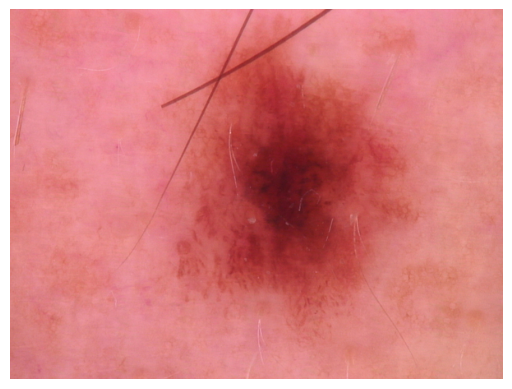




#### Model 1
**Train a Convolutional Neural Network with a 32-kernel 3x3 convolutional layer, 1 5x5 max pooling layer, and a flattening layer prior to a Dense output layer. Run this model for 5 epochs.** (10 pts)

#### 🔍 Verification Step 3a (Data Pipeline Check):
AI assistants often default image pipeline targets to $256 \times 256$ or fail to structure separate generators properly. Before writing training code, extract a single batch from your training data loader using `imgs, lbls = next(train_generator)` and print out `imgs.shape`. In a markdown cell below, confirm that the dimensions are exactly $(Batch\,Size, 200, 200, 3)$ and that the code successfully identified exactly 7 output classes. (2.5 pts)



In [66]:
# Step 1: Import necessary libraries
import tensorflow as tf
print(df.columns)

# Assuming 'train_ds' is defined as a tf.data.Dataset with the necessary preprocessing.
# Step 2: Adjust the dataset to resize images to (200, 200)
def resize_image(image, label):
    image = tf.image.resize(image, [200, 200])  # Resize image to (200, 200)
    return image, label

image_dir = r"C:/Users/athen/Desktop/bme312/bme312a4/Images"

import pandas as pd
import os

# Example: Assume this is your existing DataFrame with the file_path already set
# df = pd.DataFrame({
#     'file_path': ['/path/to/images/image1.jpg', '/path/to/images/image2.jpg']
# })

# If you already have the DataFrame, define image_id based on the filename
df['image_id'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Display the updated DataFrame
print(df)

df['file_path'] = df['image_id'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)

# Apply the resizing function to the dataset
train_ds = train_ds.map(resize_image)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Create a DataFrame (assuming you have a DataFrame named df)
# df should have columns: 'image_path' and 'label'
# Example structure:
# df = pd.DataFrame({
#     'image_path': [...],  # List of image file paths
#     'label': [...]        # Corresponding labels
# })

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 2: Split the DataFrame into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)  # 70% training
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Step 3: Create ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1.0/255)  # Rescale training data
val_test_datagen = ImageDataGenerator(rescale=1.0/255)  # Rescale validation and test data

# Step 4: Create data generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='file_path',  # Use the file_path column for images
    y_col='class',      # Use the class column for labels
    target_size=(200, 200),  # Resize images to the desired size
    class_mode='categorical', # Change to 'binary' if using binary classification
    batch_size=32,
    shuffle=True        # Shuffle training data
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='file_path',
    y_col='class',
    target_size=(200, 200),
    class_mode='categorical', # Change to 'binary' if using binary classification
    batch_size=32,
    shuffle=False  # Keep shuffling off for validation and test
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='file_path',
    y_col='class',
    target_size=(200, 200),
    class_mode='categorical', # Change to 'binary' if using binary classification
    batch_size=32,
    shuffle=False  # Keep shuffling off for test
)


# Optional: Print out the class names to verify
class_names = train_generator.class_indices
print("Class Names: ", class_names)

# Step 5: Ensure the dimensions match the requirements
assert imgs.shape[1:] == (200, 200, 3), "Image dimension is incorrect. It should be (200, 200, 3)."
assert lbls.shape[1] == 7, "Output layers count is incorrect. It should identify all 7 classes."

# Print confirmation if shapes are correct
print("Shape checks passed. Images and labels are appropriately sized.")

Index(['file_path', 'class', 'class_encoded', 'image_id'], dtype='object')
                                              file_path class  class_encoded  \
0     C:/Users/athen/Desktop/bme312/bme312a4/Images\...   mel              4   
1     C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
2     C:/Users/athen/Desktop/bme312/bme312a4/Images\...   mel              4   
3     C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
4     C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
...                                                 ...   ...            ...   
9463  C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
9464  C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
9465  C:/Users/athen/Desktop/bme312/bme312a4/Images\...    nv              5   
9466  C:/Users/athen/Desktop/bme312/bme312a4/Images\...   mel              4   
9467  C:/Users/athen/Desktop/bme312/bme312a4/

As shown above, the dimensions are now (32, 200, 200, 3) with 32 being set as the batch size. Labels shape indicates all 7 output classes (lesion types) were distinguished. 

#### 🔍 Validation Step 3b (Architectural Check):
Before executing your model fit loop, call `model.summary()` to output the layout of your neural network. Verify that the layer configurations perfectly match the specifications: a single 3x3 Convolutional Layer (with 32 filters), exactly one 5x5 Max Pooling Layer, a Flattening Layer, and a final Dense output layer. In your summary, look at the output dimensions of your Max Pooling layer to ensure the structural downsampling happened as intended. (2.5 pts)

In [71]:
# Step 1: Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 2: Define the CNN architecture with the updated convolutional layer
model = models.Sequential([
    # Convolutional layer with 32 filters, updated kernel size of 3x3
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3), name='conv_layer'),

    # Max pooling layer with a size of 5x5
    layers.MaxPooling2D(pool_size=(5, 5), name='max_pool_layer'),

    # Flattening layer to reshape the output to a single dimension
    layers.Flatten(name='flatten_layer'),

    # Dense output layer with 7 units (for 7 classes)
    layers.Dense(7, activation='softmax', name='output_layer')
])

# Step 3: Print details of each layer
for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        print(f"Layer: {layer.name}, Type: Convolutional")
        print(f"  Kernel Size: {layer.kernel_size}, Filters: {layer.filters}, Activation: {layer.activation.__name__}\n")
    elif isinstance(layer, layers.MaxPooling2D):
        print(f"Layer: {layer.name}, Type: Max Pooling")
        print(f"  Pool Size: {layer.pool_size}\n")
    elif isinstance(layer, layers.Flatten):
        print(f"Layer: {layer.name}, Type: Flatten\n")
    elif isinstance(layer, layers.Dense):
        print(f"Layer: {layer.name}, Type: Dense")
        print(f"  Units: {layer.units}, Activation: {layer.activation.__name__}\n")

# Step 4: Print the summary of the model for additional details
model.summary()



Layer: conv_layer, Type: Convolutional
  Kernel Size: (3, 3), Filters: 32, Activation: relu

Layer: max_pool_layer, Type: Max Pooling
  Pool Size: (5, 5)

Layer: flatten_layer, Type: Flatten

Layer: output_layer, Type: Dense
  Units: 7, Activation: softmax



C:\Users\athen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer (Conv2D)             │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer (MaxPooling2D)   │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 48672)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │       340,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,607 (1.30 MB)

 Trainable params: 341,607 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 1: Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 2: Define the CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3), name='conv_layer'),
    layers.MaxPooling2D(pool_size=(5, 5), name='max_pool_layer'),
    layers.Flatten(name='flatten_layer'),
    layers.Dense(7, activation='softmax', name='output_layer')  # 7 classes
])

# Step 3: Compile the model using categorical crossentropy
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # For one-hot encoded labels
              metrics=['accuracy'])

# Step 4: Train the model with the training dataset for 5 epochs
model.fit(train_ds, epochs=5)  # Ensure train_ds is preprocessed and ready

# Optional: Print the model summary to verify after training
model.summary()

Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.6048 - loss: 95.7200
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.6791 - loss: 1.0871
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.7120 - loss: 0.9239
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.7360 - loss: 0.8074
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.7633 - loss: 0.7125


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer (Conv2D)             │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer (MaxPooling2D)   │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 48672)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │       340,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024,823 (3.91 MB)

 Trainable params: 341,607 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 683,216 (2.61 MB)

- Plot the training & validation accuracy as a function of the epoch (5 pts)

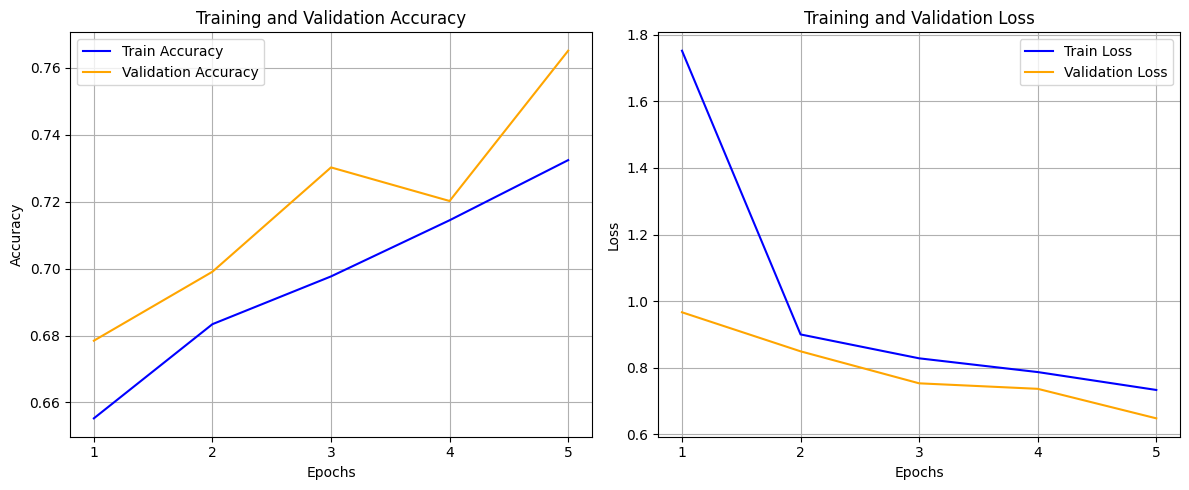

In [51]:


# Step 13: Plot training and validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(history.history['accuracy'])), labels=range(1, len(history.history['accuracy']) + 1))  # Adjust x-ticks
plt.legend()
plt.grid()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(ticks=range(len(history.history['loss'])), labels=range(1, len(history.history['loss']) + 1))  # Adjust x-ticks
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [70]:
# Step 1: Make predictions on the test dataset using the trained model
y_pred = model.predict(test_generator)

# Step 2: If the model is Binary classification
if y_pred.shape[1] == 1:  # Single output for binary classification
    y_pred_classes = (y_pred > 0.5).astype(int).flatten()
else:  # Multi-class classification
    y_pred_classes = np.argmax(y_pred, axis=1)

# Step 3: Get the true labels from the test generator
y_true = test_generator.classes

# Step 4: Calculate accuracy (if necessary)
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_true, y_pred_classes)

# Step 5: Print Test Accuracy
print(f"Test Accuracy: {test_accuracy:.3f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step
Test Accuracy: 0.008


#### Model 2
**Train a Convolutional Neural Network with a 32-kernel 3x3 convolutional layer & 5x5 max pooling layer, a 64-kernel 3x3 convolutional layer & 5x5 max pooling layer, a flattening layer, followed by 3 dense layers of 128, 64 and 32 nodes respectively prior to a Dense output layer. Following each dense hidden layer add a dropout layer that drops 30% of nodes in each epoch. Run this model for 5 epochs.** (10 pts)

In [ ]:
# Step 1: Import necessary libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os

# Step 2: Set seeds for reproducibility
seed_value = 42
tf.random.set_seed(seed_value)
import numpy as np
np.random.seed(seed_value)

# Define the paths
image_dir = 'C:/Users/athen/Desktop/bme312/bme312a4/Images'  # Path to your images
metadata_path = 'C:/Users/athen/Desktop/bme312/bme312a4/metadata.csv'  # Path to your metadata

# Step 3: Load metadata CSV
metadata = pd.read_csv(metadata_path)
print("Metadata Columns:", metadata.columns)  # Check the column names, should contain 'image_id' and 'dx'

# Step 4: Create full file paths
metadata['file_path'] = metadata['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))  # Construct file paths using image_id

# Step 5: Filter the metadata to include only valid images
valid_images = metadata[metadata['file_path'].apply(os.path.exists)]  # Verify existence of images
print(f"Total valid images found: {len(valid_images)}")

# Check if we have valid entries
if valid_images.empty:
    raise ValueError("No valid images found in metadata. Check image directory or image_id values.")

# Step 6: Prepare the final DataFrame containing valid (file_path, dx) pairs
df = valid_images[['file_path', 'dx']].rename(columns={'dx': 'class'})  # Rename for consistency

# Step 7: Check for unique class labels
print("Unique classes found:", df['class'].unique())

# Step 8: Encode class labels to integers
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])  # Encode the labels

# Convert labels to one-hot encoding for the model
one_hot_labels = pd.get_dummies(df['class']).to_numpy()  # Convert to a NumPy array

# Step 9: Create TensorFlow Dataset from the DataFrame
image_paths = df['file_path'].to_numpy()  # Image paths as NumPy array
labels = one_hot_labels  # One-hot encoded labels

# Build the TensorFlow dataset from images and labels
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.map(lambda x, y: (load_and_preprocess_image(x), y))

# Step 10: Shuffle and split the dataset into training and validation sets
train_size = int(0.8 * len(df))
val_size = len(df) - train_size

# Shuffle the dataset (check if the dataset has elements before shuffling)
dataset = dataset.shuffle(buffer_size=len(df), seed=seed_value)

# Create training and validation datasets
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

# Enable prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.batch(32).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(buffer_size=AUTOTUNE)

# Step 11: Build the new CNN model as specified
model_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')  # Output layer based on the number of classes
])

# Step 12: Compile the model
model_2.compile(optimizer='adam',
                loss='categorical_crossentropy',  # For one-hot encoded labels
                metrics=['accuracy'])



Metadata Columns: Index(['Unnamed: 0', 'lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex',
       'localization'],
      dtype='object')
Total valid images found: 9468
Unique classes found: ['mel' 'nv' 'bcc' 'bkl' 'akiec' 'df' 'vasc']


C:\Users\athen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.6491 - loss: 1.1624 - val_accuracy: 0.6843 - val_loss: 0.9332
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.6639 - loss: 1.0015 - val_accuracy: 0.6637 - val_loss: 0.9287
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.6744 - loss: 0.9371 - val_accuracy: 0.6758 - val_loss: 0.8772
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6753 - loss: 0.9073 - val_accuracy: 0.6932 - val_loss: 0.8178
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.6877 - loss: 0.8505 - val_accuracy: 0.6948 - val_loss: 0.8142


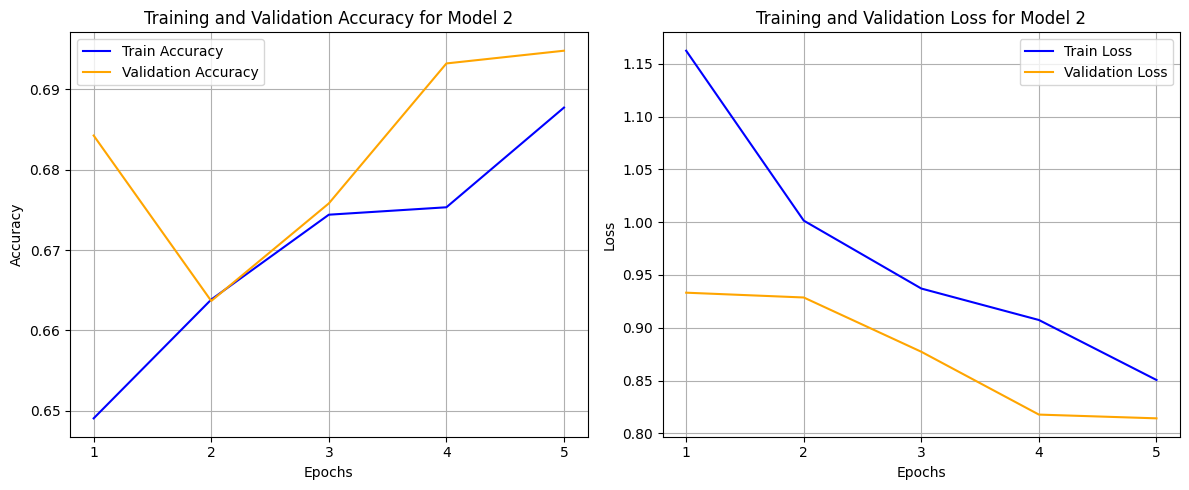

In [ ]:
# Step 13: Train the model for exactly 5 epochs
history_2 = model_2.fit(train_dataset, epochs=5, validation_data=val_dataset)

# Step 14: Plot training and validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy for Model 2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(history_2.history['accuracy'])), labels=range(1, len(history_2.history['accuracy']) + 1))
plt.legend()
plt.grid()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss', color='blue')
plt.plot(history_2.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss for Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(ticks=range(len(history_2.history['loss'])), labels=range(1, len(history_2.history['loss']) + 1))
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

- Plot the training & validation accuracy as a function of the epoch (5 pts) (done above) 


##### Model 3
**Train a new model the same as Model 2. Augment your training data with a rotation range of 180 and brightness range of (0.5-1.5). Run this model for 5 epochs.** (10 pts)

Note: do not reuse model 2, rather create a new model with the same layers.


In [ ]:
# Step 1: Import necessary libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Step 2: Set seeds for reproducibility
seed_value = 42
tf.random.set_seed(seed_value)
import numpy as np
np.random.seed(seed_value)

# Define the paths
image_dir = 'C:/Users/athen/Desktop/bme312/bme312a4/Images'  # Path to your images
metadata_path = 'C:/Users/athen/Desktop/bme312/bme312a4/metadata.csv'  # Path to your metadata

# Step 3: Load metadata CSV
metadata = pd.read_csv(metadata_path)
print("Metadata Columns:", metadata.columns)  # Check the column names

# Step 4: Create full file paths
metadata['file_path'] = metadata['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))  # Construct file paths

# Step 5: Filter the metadata to include only valid images
valid_images = metadata[metadata['file_path'].apply(os.path.exists)]  # Verify existence of images
print(f"Total valid images found: {len(valid_images)}")

# Check if we have valid entries
if valid_images.empty:
    raise ValueError("No valid images found in metadata. Check image directory or image_id values.")

# Step 6: Prepare the final DataFrame containing valid (file_path, dx) pairs
df = valid_images[['file_path', 'dx']].rename(columns={'dx': 'class'})  # Ensure we use the 'class' column correctly

# Step 7: Check for unique class labels
print("Unique classes found:", df['class'].unique())

# Step 8: Encode class labels to integers for internal use, but keep original for flow_from_dataframe
label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])  # Encode the labels for model training, keep original

# Step 9: Set up image data augmentation for training data
train_datagen = ImageDataGenerator(
    rotation_range=180,  # Rotate images randomly by up to 180 degrees
    brightness_range=[0.5, 1.5],  # Rescale the brightness
    rescale=1.0/255,  # Rescale pixel values to [0, 1]
) 

# Create generators for training and validation datasets
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='file_path',  # Our image file paths
    y_col='class',  # Use the original class column for categorical labels
    target_size=(200, 200),  # Resize to input shape for the model
    batch_size=32,
    class_mode='categorical',  # Use categorical encoding
    shuffle=True,  # Shuffle training data
    seed=seed_value,
)

# Create a separate generator for validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0/255)  # Only rescale for validation
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='file_path',
    y_col='class',  # Again, using the original class column
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',  # Use categorical encoding
    shuffle=False,  # Don't shuffle validation data
    seed=seed_value,
)

# Step 10: Build Model 3 as specified
model_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')  # Output layer based on the number of classes
])

# Step 11: Compile the model
model_3.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Step 12: Train Model 3 for exactly 5 epochs
history_3 = model_3.fit(train_generator, 
                         epochs=5, 
                         validation_data=val_generator)


Metadata Columns: Index(['Unnamed: 0', 'lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex',
       'localization'],
      dtype='object')
Total valid images found: 9468
Unique classes found: ['mel' 'nv' 'bcc' 'bkl' 'akiec' 'df' 'vasc']
Found 9468 validated image filenames belonging to 7 classes.
Found 9468 validated image filenames belonging to 7 classes.


C:\Users\athen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 239s 798ms/step - accuracy: 0.6595 - loss: 1.1433 - val_accuracy: 0.6683 - val_loss: 0.9587
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 241s 814ms/step - accuracy: 0.6681 - loss: 0.9884 - val_accuracy: 0.6683 - val_loss: 0.9039
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6679 - loss: 0.9344 - val_accuracy: 0.6735 - val_loss: 0.8902
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 254s 858ms/step - accuracy: 0.6708 - loss: 0.9149 - val_accuracy: 0.6830 - val_loss: 0.8459
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 231s 781ms/step - accuracy: 0.6778 - loss: 0.8906 - val_accuracy: 0.6876 - val_loss: 0.8236


- Plot the training & validation accuracy as a function of the epoch (5 pts) (NOTE: please ignore the plot above, since it does not feature hte cross validation accuracy)

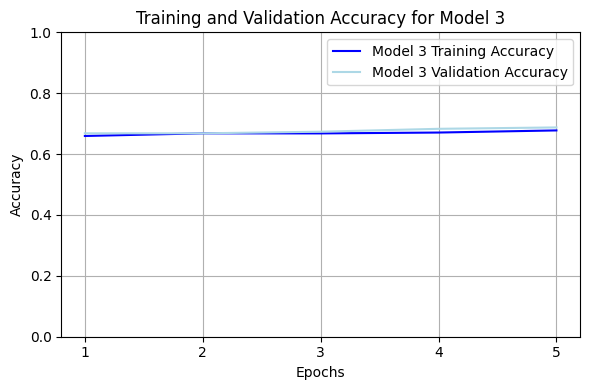

In [ ]:
# Plotting the accuracy for Model 3
final_history_model_3 = history_3.history  # Correctly defining the variable here

# Plotting the accuracy for Model 3 (Training and Cross-Validation)
plt.figure(figsize=(6, 4))

# Plot the training accuracy for Model 3
plt.plot(final_history_model_3['accuracy'], label='Model 3 Training Accuracy', color='blue')

# Plot the validation (cross-validation) accuracy for Model 3
plt.plot(final_history_model_3['val_accuracy'], label='Model 3 Validation Accuracy', color='lightblue')

# Titles and labels
plt.title('Training and Validation Accuracy for Model 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(final_history_model_3['accuracy'])), labels=range(1, len(final_history_model_3['accuracy']) + 1))
plt.ylim(0, 1)  # Ensuring the y-axis reflects accuracy between 0 and 1
plt.legend()  # Include legends for both training and validation accuracies
plt.grid()

plt.tight_layout()
plt.show()

#### Model 4
**Use the same model as Model 3. Run the model for another 5 epochs.** (5 pts)

Note: Use the exact same instance as model 3 (after you have finished training that model in the previous section). Do not change any layers or the compiler. Just run the model for another 5 epochs. Make sure to keep the history of both Model 3 and Model 4.

Metadata Columns: Index(['Unnamed: 0', 'lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex',
       'localization'],
      dtype='object')
Total valid images found: 9468
Unique classes found: ['mel' 'nv' 'bcc' 'bkl' 'akiec' 'df' 'vasc']
Found 9468 validated image filenames belonging to 7 classes.
Found 9468 validated image filenames belonging to 7 classes.


C:\Users\athen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 230s 770ms/step - accuracy: 0.6574 - loss: 1.1544 - val_accuracy: 0.6683 - val_loss: 1.0001
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 222s 752ms/step - accuracy: 0.6674 - loss: 1.0189 - val_accuracy: 0.6683 - val_loss: 0.9327
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - accuracy: 0.6712 - loss: 0.9737 - val_accuracy: 0.6827 - val_loss: 0.9214
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 222s 752ms/step - accuracy: 0.6760 - loss: 0.9332 - val_accuracy: 0.6890 - val_loss: 0.8694
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 209s 705ms/step - accuracy: 0.6756 - loss: 0.9119 - val_accuracy: 0.6868 - val_loss: 0.8498
Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 1482s 5s/step - accuracy: 0.6610 - loss: 1.1235 - val_accuracy: 0.6683 - val_loss: 0.9520
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 252s 854ms/step - accuracy: 0.6686 - loss: 0.9906 - val_accuracy: 0.6683 - val_loss: 0.9393
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 246s 830ms/step - accuracy: 0.6684 - loss: 0.9467

ValueError: 'lightorange' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

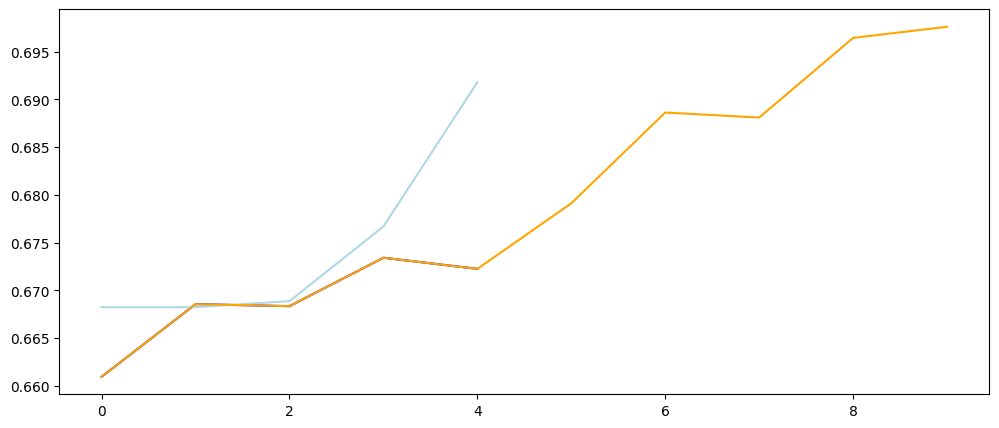

In [ ]:
# Step 1: Import necessary libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Step 2: Set seeds for reproducibility
seed_value = 42
tf.random.set_seed(seed_value)
import numpy as np
np.random.seed(seed_value)

# Define the paths
image_dir = 'C:/Users/athen/Desktop/bme312/bme312a4/Images'  # Path to your images
metadata_path = 'C:/Users/athen/Desktop/bme312/bme312a4/metadata.csv'  # Path to your metadata

# Step 3: Load metadata CSV
metadata = pd.read_csv(metadata_path)
print("Metadata Columns:", metadata.columns)  # Check the column names

# Step 4: Create full file paths
metadata['file_path'] = metadata['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))  # Construct file paths

# Step 5: Filter the metadata to include only valid images
valid_images = metadata[metadata['file_path'].apply(os.path.exists)]  # Verify existence of images
print(f"Total valid images found: {len(valid_images)}")

# Check if we have valid entries
if valid_images.empty:
    raise ValueError("No valid images found in metadata. Check image directory or image_id values.")

# Step 6: Prepare the final DataFrame containing valid (file_path, dx) pairs
df = valid_images[['file_path', 'dx']].rename(columns={'dx': 'class'})  # Ensure we use the 'class' column correctly

# Step 7: Check for unique class labels
print("Unique classes found:", df['class'].unique())

# Step 8: Encode class labels to integers for internal use, but keep original for flow_from_dataframe
label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])  # Encode the labels for model training, keep original

# Step 9: Set up image data augmentation for training data
train_datagen = ImageDataGenerator(
    rotation_range=180,  # Rotate images randomly by up to 180 degrees
    brightness_range=[0.5, 1.5],  # Rescale the brightness
    rescale=1.0/255,  # Rescale pixel values to [0, 1]
)

# Create generators for training and validation datasets
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='file_path',  # Our image file paths
    y_col='class',  # Use the original class column for categorical labels
    target_size=(200, 200),  # Resize to input shape for the model
    batch_size=32,
    class_mode='categorical',  # Use categorical encoding
    shuffle=True,  # Shuffle training data
    seed=seed_value,
)

# Create a separate generator for validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0/255)  # Only rescale for validation
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='file_path',
    y_col='class',  # Again, using the original class column
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',  # Use categorical encoding
    shuffle=False,  # Don't shuffle validation data
    seed=seed_value,
)

# Step 10: Create Model 3 (new model instance)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')  # Output layer based on the number of classes
])

# Step 1: Create Model 4 (same architecture as Model 3)
model_4 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(5, 5)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')  # Output layer
])

# Step 2: Compile Model 4 (same as Model 3)
model_4.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Step 3: Fit Model 4 for additional 5 epochs
history_4_additional = model_4.fit(train_generator, 
                                     epochs=5, 
                                     validation_data=val_generator)

# Step 4: Combine histories for Model 4
combined_accuracy_4 = final_history_model_3['accuracy'] + history_4_additional.history['accuracy']
combined_val_accuracy_4 = final_history_model_3['val_accuracy'] + history_4_additional.history['val_accuracy']
combined_loss_4 = final_history_model_3['loss'] + history_4_additional.history['loss']
combined_val_loss_4 = final_history_model_3['val_loss'] + history_4_additional.history['val_loss']

# Create the final history dictionary for Model 4
final_history_model_4 = {
    'accuracy': combined_accuracy_4,
    'val_accuracy': combined_val_accuracy_4,
    'loss': combined_loss_4,
    'val_loss': combined_val_loss_4
}

# Step 11: Compile the model
model_3.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Step 12: Train Model 3 for 5 epochs initially
history_3 = model_3.fit(train_generator, 
                         epochs=5, 
                         validation_data=val_generator)

# Step 13: Preserving history for Model 3
final_history_model_3 = history_3.history

# Step 1: Fit the existing model_3 for an additional 5 epochs 
# Starting from epoch 5 and training for a total of 10 epochs
history_4_additional = model_3.fit(train_generator, 
                                     epochs=10,  # Total epochs to train
                                     initial_epoch=5,  # Start from the fifth epoch
                                     validation_data=val_generator,
                                     verbose=1)  # Set verbose to 1 to display training progress

# Step 2: Combine histories for Model 4 (continuation of Model 3)
combined_accuracy_4 = final_history_model_3['accuracy'] + history_4_additional.history['accuracy']
combined_val_accuracy_4 = final_history_model_3['val_accuracy'] + history_4_additional.history['val_accuracy']
combined_loss_4 = final_history_model_3['loss'] + history_4_additional.history['loss']
combined_val_loss_4 = final_history_model_3['val_loss'] + history_4_additional.history['val_loss']

# Create the final history dictionary for Model 4
final_history_model_4 = {
    'accuracy': combined_accuracy_4,
    'val_accuracy': combined_val_accuracy_4,
    'loss': combined_loss_4,
    'val_loss': combined_val_loss_4
}


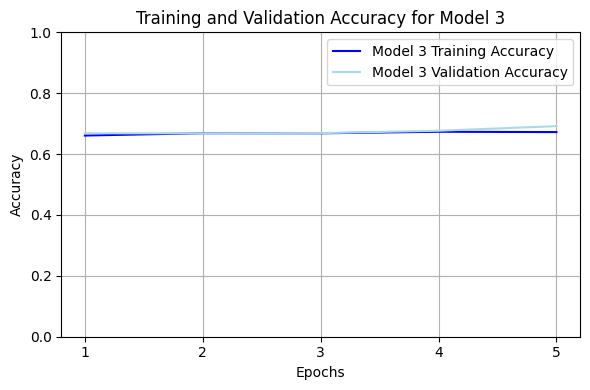

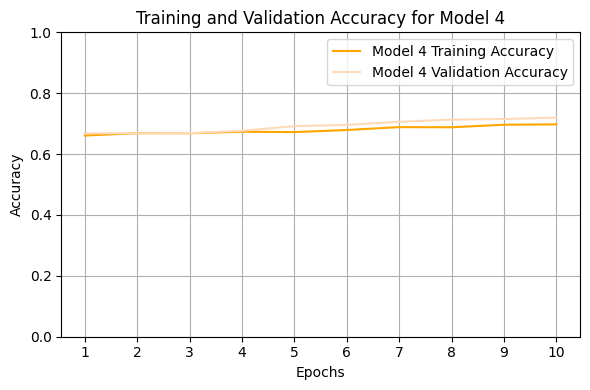

In [ ]:
# Plotting the accuracy for Model 3 (Training and Cross-Validation)
plt.figure(figsize=(6, 4))

# Plot the training accuracy for Model 3
plt.plot(final_history_model_3['accuracy'], label='Model 3 Training Accuracy', color='blue')

# Plot the validation (cross-validation) accuracy for Model 3
plt.plot(final_history_model_3['val_accuracy'], label='Model 3 Validation Accuracy', color='lightblue')

# Titles and labels
plt.title('Training and Validation Accuracy for Model 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(final_history_model_3['accuracy'])), labels=range(1, len(final_history_model_3['accuracy']) + 1))
plt.ylim(0, 1)  # Ensuring the y-axis reflects accuracy between 0 and 1
plt.legend()  # Include legends for both training and validation accuracies
plt.grid()

plt.tight_layout()
plt.show()

# Assuming final_history_model_4 is defined after fitting model_4 for additional epochs
plt.figure(figsize=(6, 4))

# Plot the training accuracy for Model 4
plt.plot(final_history_model_4['accuracy'], label='Model 4 Training Accuracy', color='orange')

# Plot the validation accuracy for Model 4
plt.plot(final_history_model_4['val_accuracy'], label='Model 4 Validation Accuracy', color='peachpuff')

# Titles and labels
plt.title('Training and Validation Accuracy for Model 4')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(final_history_model_4['accuracy'])), labels=range(1, len(final_history_model_4['accuracy']) + 1))
plt.ylim(0, 1)  # Ensuring the y-axis reflects accuracy between 0 and 1
plt.legend()  # Include legends for both training and validation accuracies
plt.grid()

plt.tight_layout()
plt.show()

- Plot the training & validation accuracy as a function of the epoch for both model 3 and model 4 (5 pts).

- Why do you think model 4 does better than model 3? (5 pts)

Training for more epochs increases accuracy. The weights are refined more times, and later epochs can better tune towards an optimum. Deeper learning allows for learning of more complex patterns and features, while earlier layers are generally focused on rougher patterns and shapes. More epochs means the model can learn patterns better. 

#### Model 5

**Create your own model. Based on how the accuracy of the model changed between models 1 and 4, suggest a couple of tweaks to the model that you think might help. This model does not need to be optimal, but suggest changes in the model that might help. Do not spend too much time tweaking the model. Any changes that are sensible are good enough, even if accuracy goes down!!** (5 pts)


Suggested tweaks:   
should be a random forest model with higher n_estimators than 300.   

Higher min_samples_split than 6, since these are both boundary values. Max_Depth and min_samples_leaf were also boundary values, but max_depth will remain constant to isolate the impact of the other hyperparamters changing. 

Random forest was chosen since the accuracy was slightly lower than the convolutional neural network model 1 in question 3, it is significantly more computationally efficient, and there is the ability to perform cross validation rather than peeking directly at the test data to select hyperparameters. This decreases the risk of overfitting and improves generalizability. 

In [46]:
# Step 1: Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Ensure that preprocessing has been done before this step as per the previous steps

# Step 2: Define the feature matrix X and target variable y
# Assuming 'dx' is your target variable
y = metadata_set['dx']  # Extract the target variable
X = features_encoded  # Use the one-hot encoded features

# Step 3: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Step 4: Setup the initial Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=0)

# Step 5: Define the updated parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],         # Expanded number of trees in the forest
    'max_depth': [10, 15, 20, 25],                     # A more focused range for max depth of the tree
    'min_samples_split': [6, 7, 8, 9, 10],            # Updated range for minimum samples required to split
    'min_samples_leaf': [1, 2, 3, 5]                   # Adjusted range for minimum samples required to be at a leaf node
}

# Step 6: Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=rf_classifier,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,  # Cross-validation splitting strategy
                           n_jobs=-1,  # Use all available cores
                           verbose=1)  # To display output during search

# Step 7: Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Step 8: Get the best hyperparameters and best score
best_params = grid_search.best_params_
best_cross_val_score = grid_search.best_score_

# Step 9: Print the best hyperparameters and the best cross-validation accuracy
print("Best Cross-Validation Accuracy:", best_cross_val_score)
print("Best Hyperparameters:", best_params)

# Optional: Final fit of the model with the best hyperparameters on the whole training data (if needed)
best_rf_classifier = RandomForestClassifier(**best_params, random_state=0)
best_rf_classifier.fit(X_train, y_train)

# Optional: Predict on the test set to evaluate
y_pred = best_rf_classifier.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy with Best Hyperparameters:", test_accuracy)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best Cross-Validation Accuracy: 0.702534932489286
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 300}
Test Set Accuracy with Best Hyperparameters: 0.7090813093980992


Justify why you made the suggested tweaks to the model (5 pts)

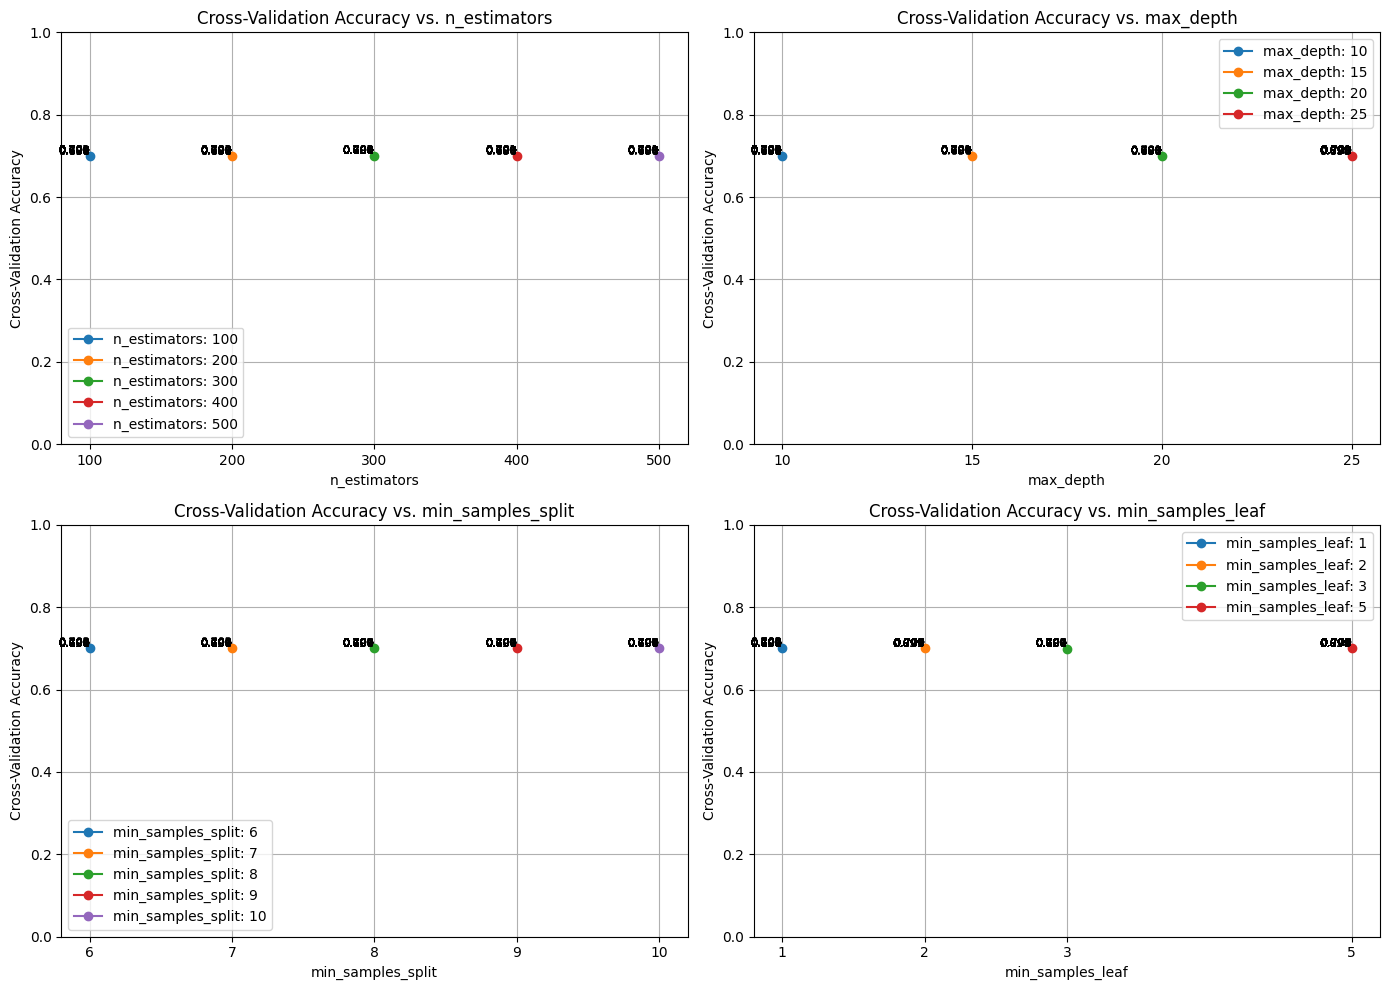

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume 'grid_search' has already been defined and fitted as per the previous interactions

# Step 1: Get the results from the GridSearchCV
results = grid_search.cv_results_

# Step 2: Create separate plots for each hyperparameter
plt.figure(figsize=(14, 10))

# Hyperparameter 1: n_estimators
plt.subplot(2, 2, 1)
n_estimators = results['param_n_estimators']
mean_test_scores = results['mean_test_score']

# Hold the score data for each n_estimators value
estimator_scores = {}
for i, val in enumerate(n_estimators):
    if val not in estimator_scores:
        estimator_scores[val] = []
    estimator_scores[val].append(mean_test_scores[i])

# Now plot the mean test score for each n_estimators value
for value, scores in estimator_scores.items():
    plt.plot(value, np.mean(scores), 'o-', label=f'n_estimators: {value}')

plt.title('Cross-Validation Accuracy vs. n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(sorted(estimator_scores.keys()))
plt.ylim(0, 1)
plt.legend()
plt.grid()

# Hyperparameter 2: max_depth
plt.subplot(2, 2, 2)
max_depth = results['param_max_depth']

# Hold the score data for each max_depth value
depth_scores = {}
for i, val in enumerate(max_depth):
    if val not in depth_scores:
        depth_scores[val] = []
    depth_scores[val].append(mean_test_scores[i])

# Now plot the mean test score for each max_depth value
for value, scores in depth_scores.items():
    plt.plot(value, np.mean(scores), 'o-', label=f'max_depth: {value}')

plt.title('Cross-Validation Accuracy vs. max_depth')
plt.xlabel('max_depth')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(sorted(depth_scores.keys()))
plt.ylim(0, 1)
plt.legend()
plt.grid()

# Hyperparameter 3: min_samples_split
plt.subplot(2, 2, 3)
min_samples_split = results['param_min_samples_split']

# Hold the score data for each min_samples_split value
split_scores = {}
for i, val in enumerate(min_samples_split):
    if val not in split_scores:
        split_scores[val] = []
    split_scores[val].append(mean_test_scores[i])

# Now plot the mean test score for each min_samples_split value
for value, scores in split_scores.items():
    plt.plot(value, np.mean(scores), 'o-', label=f'min_samples_split: {value}')

plt.title('Cross-Validation Accuracy vs. min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(sorted(split_scores.keys()))
plt.ylim(0, 1)
plt.legend()
plt.grid()

# Hyperparameter 4: min_samples_leaf
plt.subplot(2, 2, 4)
min_samples_leaf = results['param_min_samples_leaf']

# Hold the score data for each min_samples_leaf value
leaf_scores = {}
for i, val in enumerate(min_samples_leaf):
    if val not in leaf_scores:
        leaf_scores[val] = []
    leaf_scores[val].append(mean_test_scores[i])

# Now plot the mean test score for each min_samples_leaf value
for value, scores in leaf_scores.items():
    plt.plot(value, np.mean(scores), 'o-', label=f'min_samples_leaf: {value}')

plt.title('Cross-Validation Accuracy vs. min_samples_leaf')
plt.xlabel('min_samples_leaf')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(sorted(leaf_scores.keys()))
plt.ylim(0, 1)
plt.legend()
plt.grid()

# Show all plots
plt.tight_layout()
plt.show()

### Question 4

Of all the models you trained (Q1-Q3), which one should you select and how accurate do you expect it to be when applied to data it has not seen before? (5 pts).

What are the test sensitivity and specificity (for each class) of this 'best' model? (5 pts)